If the ligand signal is not recoverable in the data, we cannot expect scLEMBAS to learn perturbation separation. Rather, let's subset to the stronger perturbations in the dataset. 

Here, we rank order perturbations. Next, we select only those that are significantly separated from control.

In [1]:
import os

from tqdm import trange

import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

import scperturb as scp

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = '1'
os.environ["MKL_NUM_THREADS"] = '1'
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ["VECLIB_MAXIMUM_THREADS"] = '1'
os.environ["NUMEXPR_NUM_THREADS"] = '1'

# Identify Strong Perturbations

In [3]:
tf_adata = io.read_tfad(os.path.join(data_path, 'interim', author + '_tf_activity_all_withls.h5ad'))


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'

# latent_label = 'pca'


In [5]:
# filter PCA space to number of components (since scperturb edist just takes them all)
tf_adata_sub = tf_adata.copy()
n_components = tf_adata_sub.uns['pca']['pca_rank']
tf_adata_sub.obsm['X_pca'] = tf_adata_sub.obsm['X_pca'][:, :n_components]

In [6]:
def bootstrap_median_ci(x, n_boot=5000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    boots = np.array([np.median(rng.choice(x, size=len(x), replace=True))
                      for _ in range(n_boot)])
#     lo, hi = np.quantile(boots, [alpha/2, 1-alpha/2])
    hi = np.quantile(boots, 1 - alpha) # one-sided
    return hi


def bootstrap_delta_ci(D, p, control, n_boot=5000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)

    vp = D.loc[p].drop(p).values
    vc = D.loc[control].drop(control).values

    n = min(len(vp), len(vc))  # or resample independently

    deltas = []
    for _ in range(n_boot):
        mp = np.median(rng.choice(vp, size=n, replace=True))
        mc = np.median(rng.choice(vc, size=n, replace=True))
        deltas.append(mp - mc)

    lo, hi = np.quantile(deltas, [alpha/2, 1 - alpha/2])
    return lo, hi


In [7]:
pert_strength_categorization = 'median_difference' # 'ctrl_upper_bound' 
pert_strength_alpha = 0.05 # 95% CI 

In [8]:
# get pairwise E-distances
dist = scp.edist(
    adata = tf_adata_sub, 
    obs_key = pert_col, 
    obsm_key = 'X_pca', 
    pwd = None, 
    dist = 'sqeuclidean', 
    sample_correct=True, 
    n_jobs = n_cores, 
    verbose = False
)

# aggregate by median across perturbations 
pert_strength = {}
for p in dist.index:
    row = dist.loc[p, :].drop(p)   # exclude self
    pert_strength[p] = row.median()
    
pert_strength = pd.DataFrame(data = {'perturbation': pert_strength.keys(), 'global_sep': pert_strength.values()})
pert_strength = pert_strength.sort_values(by = 'global_sep', ascending = False).reset_index(drop = True)


# compare pert to control by CI
if pert_strength_categorization == 'ctrl_upper_bound': # filter for those median perturbations > upper bound of ctrl CI
    # get the 95% confidence interval of the median estimate for the control condition
    ctrl_vec = dist.loc[ctrl_pert].drop(ctrl_pert).values
    ctrl_hi = bootstrap_median_ci(ctrl_vec, n_boot=5000, 
                                           alpha=pert_strength_alpha, seed=seed)
    pert_strength['strong'] = pert_strength.global_sep > ctrl_hi
elif pert_strength_categorization == 'median_difference':  # filter for those median perturbations differences with ctrl with lower CI > 0
    pert_strength_map = {}
    for pert in pert_strength.perturbation:
        if pert == ctrl_pert:
            pert_strength_map[pert] = False
            continue
        lo, hi = bootstrap_delta_ci(D = dist, p = pert, control = ctrl_pert, n_boot=5000, 
                                    alpha=pert_strength_alpha, seed=seed)
        pert_strength_map[pert] = lo > 0
    pert_strength['strong'] = pert_strength.perturbation.map(pert_strength_map)

    
pert_strength.to_csv(os.path.join(data_path, 'processed', author + '_pert_strength_quantification.csv'))
pert_strength


,perturbation,global_sep,strong
0,TGFB1,169.534925,True
1,IFNG,110.255752,True
2,IFNA2,73.949282,True
3,BMP4,37.332760,True
4,IL13,37.087936,True
5,OSM,33.549607,False
6,IL17A,33.469290,False
7,CHIR99021,26.631148,False
8,FGF10,26.567259,False
9,TNFA,19.077233,False


In [9]:
strong_perts = pert_strength[pert_strength.strong].perturbation.tolist()
strong_perts += ['CTRL']

# Assess New Covariate Signal Strength

In [10]:
from scLEMBAS import latent_separation as ls

cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'
covariates = [cat_col, pert_col, 'assigned_donor', 'phase']
comparison_metric = 'chance_adjusted_accuracy'

In [11]:
no_ls_tf_adata = io.read_tfad(os.path.join(data_path, 'interim', author + '_tf_activity_all.h5ad'))
tf_adata_sub = no_ls_tf_adata[no_ls_tf_adata.obs[pert_col].isin(strong_perts)].copy()

In [13]:
tf_adata_sub, _, cv_df_pca_global_subsetted = ls.pc_pipeline(
    adata = tf_adata_sub, 
    pert_ids = tf_adata.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata.obs[cat_col].unique().tolist(),
    n_components = None, # automatically determine with elbow
    pert_col = pert_col,
    cat_col = cat_col,
    get_hvgs = False, 
    run_umap = True, 
    covariate_associations = covariates, 
    per_component_association = False, 
    global_component_association = True,
    file_prefix = os.path.join(data_path, 'interim', author + '_latent_association_strong_perts_pca'), 
    verbose = True,
    n_cores = n_cores, 
    seed = seed,
    embkwrgs = {
        'cluster_data': False, 
        'n_neighbors': 15,
        'resolution': np.nan,# [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
        'cluster_col_name': np.nan,#'TF_clusters',
        'nmi_label': np.nan,#'condition', 
        'scale': False, # TF activity is z-scored
        'pcakwrgs': {
            'use_highly_variable': False, # TF activity is z-scored
            'zero_center': False # there are no HVGs so this is by default the behavior
        }    
    }
)


Run dimensionality reductions


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculate covariate - PC associations
cell_type
ligand
assigned_donor
phase
cell_type
ligand
assigned_donor
phase


Compare the full dataset (fit in Notebook 01) to these subsetted results:

In [14]:
adata_dict = {
    'All Perturbations': tf_adata.copy(),
    'Subsetted Perturbations': tf_adata_sub.copy()
    
}

All Perturbations: Elbow selection via variance explained identified 12 as the optimal number of PCA components
Subsetted Perturbations: Elbow selection via variance explained identified 12 as the optimal number of PCA components


''

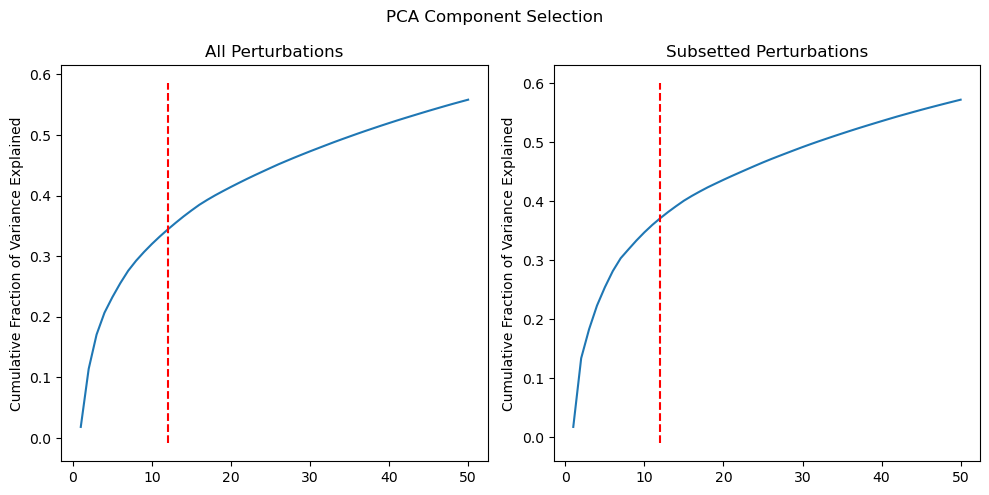

In [15]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

for (i, (adata_type, tf_adata_)) in enumerate(adata_dict.items()):
    n_pca = tf_adata_.uns['pca']['pca_rank']
    print('{}: Elbow selection via variance explained identified {} as the optimal number of PCA components'.format(adata_type, n_pca))

    cumulative_variance_ratio = np.cumsum(tf_adata_.uns['pca']['variance_ratio']) #adata.uns['pca']['variance_ratio']
    pcs = np.array(range(len(cumulative_variance_ratio))) + 1
    sns.lineplot(x = pcs, y = cumulative_variance_ratio, ax = ax[i])

    ymin, ymax = ax[i].get_ylim()
    ax[i].vlines(x = n_pca, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
                 color = 'red', linestyle = '--')
    ax[i].set_title('{}'.format(adata_type))
    ax[i].set_ylabel('Cumulative Fraction of Variance Explained')
fig.suptitle('PCA Component Selection')
fig.tight_layout()

;

<span style="color:red">If going to include this, make sure colors match between the full and subsetted data</span>


''

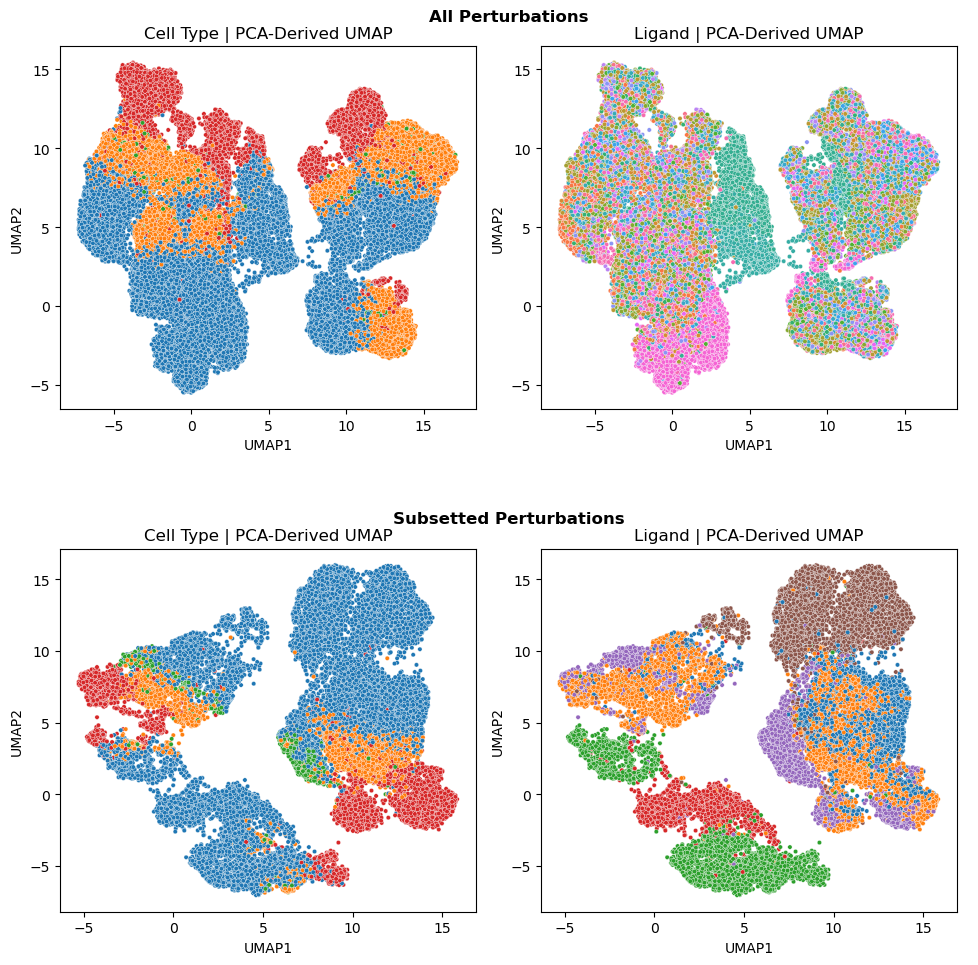

In [17]:
ncols, nrows = 2,2
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'umap': 'PCA-Derived UMAP', 
         'umap_pls': 'PLS-Derived UMAP'}

latent_label = 'umap'
for (i, (adata_type, tf_adata_)) in enumerate(adata_dict.items()):
    
    row_ax = fig.add_subplot(2, 1, i + 1, frame_on=False)
    row_ax.set_title(adata_type, fontsize=12, fontweight='bold', pad=18)
    row_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    row_ax.grid(False)
    
    
    viz_df = pd.DataFrame(tf_adata_.obsm['X_' + latent_label])
    _label_name = 'UMAP'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata_.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10)
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None:
            ax[i,j].legend_.remove()
            
        ax[i,j].set_title('{} | {}'.format(
            ' '.join([c.capitalize() for c in covariate.split('_')]), 
            ll_map[latent_label]))

fig.tight_layout()
# fig.savefig(os.path.join(data_path, 'figures', author + '_TF_umap_visualization_comparison_subsets.png'), 
#             dpi=300, bbox_inches="tight")

;

Same figure for paper:

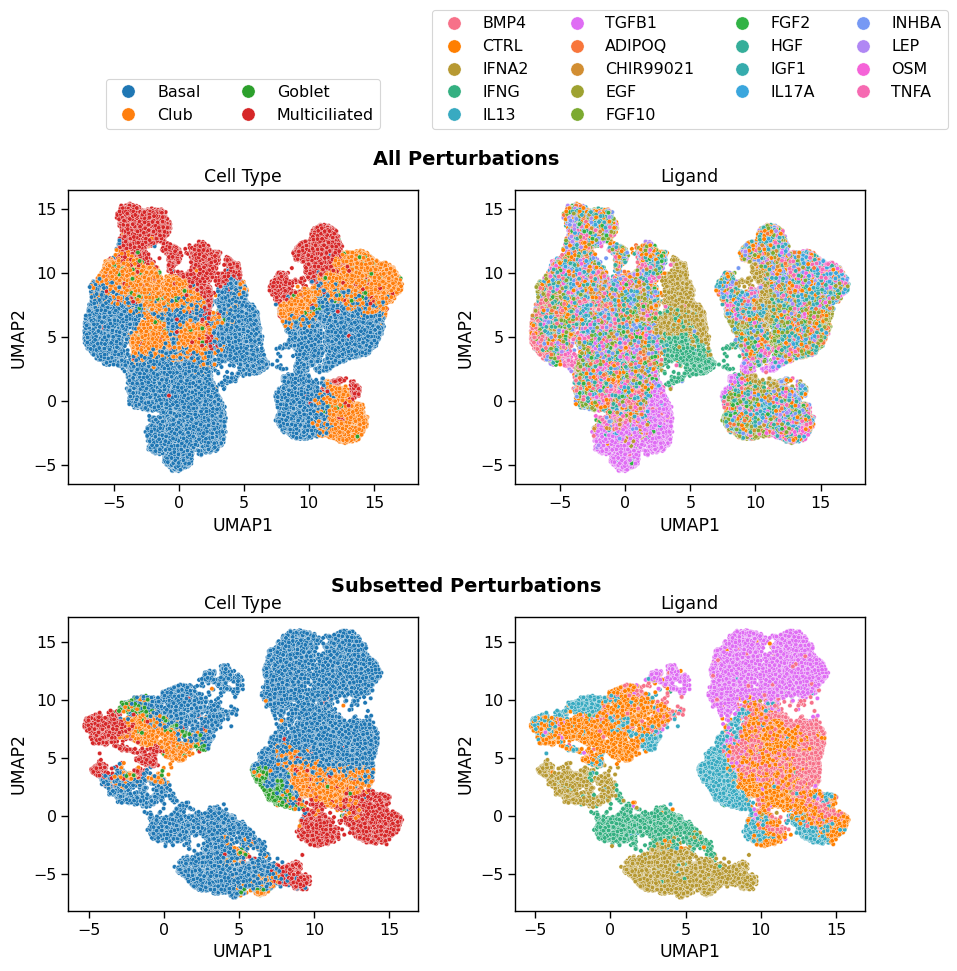

In [23]:
ncols, nrows = 2, 2
plot_type = 'scatter'

# --- perturbation ordering + color rules ------------------------------------
PERT_FIRST = sorted(['TGFB1', 'IFNG', 'IFNA2', 'BMP4', 'IL13', 'CTRL'])  # BMP4, CTRL, IFNA2, IFNG, IL13, TGFB1
SET1_ORANGE = sns.color_palette('Set1')[4]


def order_cats(cats, first=()):
    first_present = [c for c in first if c in cats]
    rest = sorted(c for c in cats if c not in first_present)
    return first_present + rest


def build_pert_palette(ordered_cats, priority=(), fixed=None):
    """husl palette where the priority categories take the most spread-out
    hues on the wheel (so the first 6 are the most distinct), CTRL pinned."""
    fixed = fixed or {}
    free = [c for c in ordered_cats if c not in fixed]
    n = len(free)
    wheel = sns.color_palette('husl', n_colors=n)  # n distinct hues

    prio_free = [c for c in priority if c in free]
    k = len(prio_free)

    # k evenly-spaced indices around the wheel -> maximally distinct hues
    prio_idx, seen = [], set()
    for t in range(k):
        idx = round(t * n / k) % n
        while idx in seen:
            idx = (idx + 1) % n
        seen.add(idx)
        prio_idx.append(idx)

    pal = {c: wheel[idx] for c, idx in zip(prio_free, prio_idx)}
    rest_idx = [i for i in range(n) if i not in seen]
    rest_cats = [c for c in free if c not in prio_free]
    pal.update({c: wheel[idx] for c, idx in zip(rest_cats, rest_idx)})
    pal.update({c: v for c, v in fixed.items() if c in ordered_cats})
    return pal


def default_cat_order(col, adata_dict):
    """Seaborn's default categorical order for the cell-type column: existing
    categorical order if present, else order of appearance in the full data."""
    first = adata_dict[list(adata_dict)[0]].obs[col]
    if pd.api.types.is_categorical_dtype(first):
        order = list(first.cat.categories)
    else:
        order = list(pd.Series(pd.concat(
            [a.obs[col].astype(object) for a in adata_dict.values()]
        )).unique())
    # append anything only present in later (subset) rows
    extra = set(pd.concat([a.obs[col].astype(str) for a in adata_dict.values()]))
    order += [c for c in sorted(extra) if c not in set(map(str, order))]
    return order


with sns.plotting_context('paper', font_scale=1.3):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows,
                           figsize=(5.1*ncols, 5.1*nrows))

    latent_label = 'umap'
    _label_name = 'UMAP'

    orders, palettes = {}, {}

    # Perturbations: custom distinct palette, shared across rows.
    pert_cats = pd.unique(pd.concat(
        [a.obs[pert_col].astype(str) for a in adata_dict.values()]
    ))
    orders[pert_col] = order_cats(pert_cats, first=PERT_FIRST)
    palettes[pert_col] = build_pert_palette(orders[pert_col],
                                            priority=PERT_FIRST,
                                            fixed={'CTRL': SET1_ORANGE})

    # Cell types: seaborn's DEFAULT palette in default order, to match the
    # original code (which passed no palette). Keyed by name -> row-consistent.
    orders[cat_col] = default_cat_order(cat_col, adata_dict)
    palettes[cat_col] = dict(zip(
        orders[cat_col], sns.color_palette(n_colors=len(orders[cat_col]))
    ))

    for (i, (adata_type, tf_adata_)) in enumerate(adata_dict.items()):

        # Bold row label, kept close to the panel; legend sits above it.
        row_ax = fig.add_subplot(2, 1, i + 1, frame_on=False)
        row_ax.set_title(adata_type, fontsize=14, fontweight='bold', pad=18)
        row_ax.tick_params(labelcolor='none', top=False, bottom=False,
                           left=False, right=False)
        row_ax.grid(False)

        viz_df = pd.DataFrame(tf_adata_.obsm['X_' + latent_label])
        viz_df.columns = [_label_name + '{}'.format(k + 1)
                          for k in range(viz_df.shape[1])]

        for covariate in [cat_col, pert_col]:
            viz_df[covariate] = tf_adata_.obs[covariate].astype(str).reset_index(drop=True)

        viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

        for (j, covariate) in enumerate([cat_col, pert_col]):
            present = set(viz_df[covariate].unique())
            hue_order = [c for c in orders[covariate] if c in present]

            if plot_type == 'scatter':
                sns.scatterplot(data=viz_df,
                                x=_label_name + '1', y=_label_name + '2',
                                hue=covariate, hue_order=hue_order,
                                palette=palettes[covariate],
                                ax=ax[i, j], s=10)
            elif plot_type == 'contour':
                sns.kdeplot(data=viz_df,
                            x=_label_name + '1', y=_label_name + '2',
                            hue=covariate, hue_order=hue_order,
                            palette=palettes[covariate],
                            ax=ax[i, j], fill=False, levels=5)

            handles, labels = ax[i, j].get_legend_handles_labels()
            if ax[i, j].get_legend() is not None:
                ax[i, j].get_legend().remove()

            ax[i, j].set_title(' '.join([c.capitalize() for c in covariate.split('_')]))

            # One legend per column, above the TOP panel, anchored high enough
            # (y=1.18) to clear the bold row title. Left -> 2 cols, top-right -> 4.
            if i == 0:
                ax[i, j].legend(handles, labels, title='',
                                ncol=4 if j == 1 else 2,
                                markerscale=3, frameon=True,
                                loc='lower center', bbox_to_anchor=(0.5, 1.18))

    fig.tight_layout()
    fig.subplots_adjust(top=0.80, hspace=0.45)
    fig.savefig(os.path.join(data_path, 'figures',
                author + '_TF_umap_visualization_comparison_subsets.png'),
                dpi=600, bbox_inches="tight", format='png', transparent = True)

In [70]:
# ncols, nrows = 2,1
# fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
# # ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# # ax = ax.flatten()
# plot_type = 'scatter'

# ll_map = {'umap': 'PCA-Derived UMAP', 
#          'umap_pls': 'PLS-Derived UMAP'}

# latent_label = 'umap'
# covariate = pert_col
# for (i, (adata_type, tf_adata_)) in enumerate(adata_dict.items()):
#     viz_df = pd.DataFrame(tf_adata_.obsm['X_' + latent_label])
#     _label_name = 'UMAP'
#     viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
#     for covariate in [cat_col, pert_col]:
#         viz_df[covariate] = tf_adata_.obs[covariate].reset_index(drop=True)
    
#     viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

#     if plot_type == 'scatter':
#         sns.scatterplot(data = viz_df, 
#                         x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
#                         ax = ax[i], s = 10)
#     elif plot_type == 'contour':
#         sns.kdeplot(data = viz_df, 
#                     x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
#                     ax = ax[i], fill = False, levels = 5)


#     if ax[i].legend_ is not None:
#         ax[i].legend_.remove()
        
#     ax[i].set_title('Ligand')

#     ax[i].set_title('{} | {}'.format(
#         ' '.join([c.capitalize() for c in covariate.split('_')]), 
#         ll_map[latent_label]))

# fig.tight_layout()

# ;

In [25]:
cv_df_pca_global_all = pd.read_csv(
    os.path.join(data_path, 'interim', author + '_latent_association_pcaglobal_pc_associations.csv'), 
    index_col = 0
)
cv_globals = {
    'All Perturbations': cv_df_pca_global_all,
    'Subsetted Perturbations': cv_df_pca_global_subsetted
             }

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future 

''

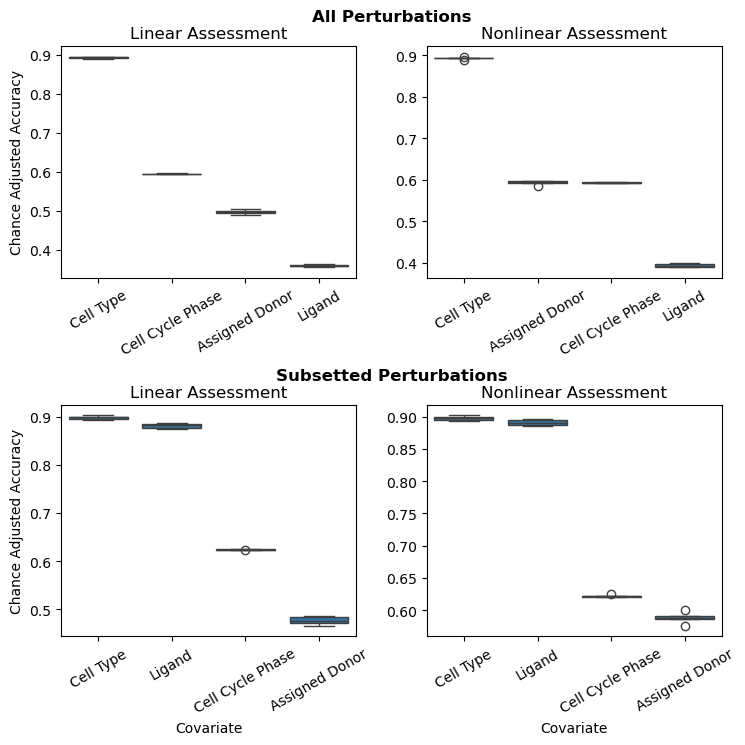

In [32]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (8, 8))

for i, (data_type, cv_global) in enumerate(cv_globals.items()):
    row_ax = fig.add_subplot(2, 1, i + 1, frame_on=False)
    row_ax.set_title(data_type, fontsize=12, fontweight='bold', pad=18)
    row_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    row_ax.grid(False)
    for j, model_type in enumerate(cv_global.model_type.unique()):
        viz_df = cv_global[cv_global.model_type == model_type]
        viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
        viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
        viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
        
        x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
        viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
        viz_df.covariate = viz_df.covariate.apply(lambda x: ' '.join([x_.capitalize() for x_ in x[:-1].split('_')]))

        
        viz_df.covariate = viz_df.covariate.replace('Phase', 'Cell Cycle Phase')
        
        sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i,j])
        for label in ax[i,j].get_xticklabels():
            label.set_rotation(30)
                    
        
        ax[i,j].set_xlabel('Covariate') if i == 1 else ax[i,j].set_xlabel('')
        ax[i,j].set_ylabel('Chance Adjusted Accuracy') if j == 0 else ax[i,j].set_ylabel('')
        ax[i,j].set_title(model_type.capitalize() + ' Assessment') #if i == 0 else ax[i,j].set_title('')
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.55)
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_ls_quantification_comparison_subsets.png'), 
            dpi=600, bbox_inches="tight")

;

# Justifying Subsetting

In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import balanced_accuracy_score
from sklearn.base import clone
from tqdm import tqdm

from scipy import stats

In [42]:
def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    nx = len(x)
    ny = len(y)

    dof = nx + ny - 2
    pooled_std = np.sqrt(
        ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof
    )

    return (x.mean() - y.mean()) / pooled_std

def pval_to_sig(p):
    if p < 5e-5: return "****"
    if p < 5e-4: return "***"
    if p < 5e-3: return "**"
    if p < 5e-2: return "*"
    return "N.S."

def add_modelwise_hue_bars(ax, res, comp_stats, x='model', y='accuracy', hue='train_data',
                           violin_width=0.8, pad_frac=0.05, bar_frac=0.01,
                           text_fmt="{sig}\nCohen's D: {d:.2f}"):
    """
    Draws a bar within each x category spanning the two hue violins, and annotates with sig + Cohen's d.
    Assumes comp_stats has one row per x category (model) with columns: model, pval, cd.
    Assumes exactly 2 hue levels.
    """

    # Establish deterministic order (matches seaborn’s categorical behavior)
    x_order = list(res[x].dropna().unique())
    hue_order = list(res[hue].dropna().unique())
    if len(hue_order) != 2:
        raise ValueError(f"Expected exactly 2 hue levels; got {len(hue_order)}: {hue_order}")

    # Positions seaborn uses (approx) when dodge=True with 2 hues:
    # centered at i, offset by +/- violin_width/4 (since each "slot" is width/2)
    # More generally: offset = (j - (n_hue-1)/2) * (violin_width / n_hue)
    n_hue = len(hue_order)
    offsets = [(j - (n_hue - 1) / 2) * (violin_width / n_hue) for j in range(n_hue)]
    x_pos = {m: (i, i + offsets[0], i + offsets[1]) for i, m in enumerate(x_order)}  # (center, left, right)

    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    pad = pad_frac * y_range
    bar_h = bar_frac * y_range

    for m in x_order:
        row = comp_stats.loc[comp_stats['model'] == m]
        if row.empty:
            continue

        p = float(row['pval'].iloc[0])
        d = float(row['cd'].iloc[0])
        sig = pval_to_sig(p)

        center, x1, x2 = x_pos[m]

        # Height: just above the highest point in that model's data
        m_ymax = res.loc[res[x] == m, y].max()
        y0 = m_ymax + pad

        # Bar: ┐──┌ style
        ax.plot([x1, x1, x2, x2], [y0, y0 + bar_h, y0 + bar_h, y0], lw=1.2, clip_on=False, color = 'black')

        # Text centered over bar
        ax.text((x1 + x2) / 2, y0 + bar_h + (0.2 * pad),
                text_fmt.format(sig=sig, d=d),
                
                ha='center', va='bottom')

    # Expand ylim if needed so annotations aren't cut off
    new_top = max(ax.get_ylim()[1], res[y].max() + 4 * pad)
    ax.set_ylim(ax.get_ylim()[0], new_top)


base_models = {
    'Linear': LogisticRegression
    (
        solver='lbfgs',
        C = 0.5, # many features, increase regularization from default 1.0
        penalty='l2',
        max_iter=3000,
        n_jobs=n_cores,
        random_state=seed,
        verbose = False
    ),
    'Nonlinear': RandomForestClassifier
    (
        random_state=seed,
        n_jobs=n_cores,
        verbose=False
    )
}

## Model Trained on All Perturbations vs Strong Perturbations

Between scripts 01 and above, we demonstrate through the same signal-quantification pipeline run on the full dataset and the subsetted one that subsetting increases the relative ligand signal substantially. In other words:
- Ligand strength in the full dataset has low signal relative to othercovariates
- Ligand strenght in the subsetted dataset has high (dominant) signal relative to other covariates

The idea here is that if there isn't signal, scLEMBAS can't learn.

However, to *fully* justify that this is in fact the case, we should do the following: Demonstrate that the model fit on the non-subsetted data has poorer performance on the same test splits than that fit on the subsetted data. 

The reasoning here is that this analysis woud show that it truly is an issue of ligand signal being drowned out during training, rather than just having easier test splits (even after chance-adjustment in the accuracy metric). 
- If the model trained on the full data performs more poorly than that trained on subsetted data on the same test split, then the issue is that perturbation signal exists but is being drowned out by weak perturbations such that it can't be captured. This justifies subsetting.
- If the model trained on the full data performs comparabley to that trained on the substted data on the same test split, then the perturbation signal that *does* exist *can* be captured, but a number of weak perturbations that shouldn't be showing signal anyways is what's being demonstrated in the overall test performance. This makes subsetting less justifiable. 

Thus, we do this here. For fair comparison, we do it in full feature space, rather than a PC space fit on each of the full and subset of samples. 

We create a 10-fold CV that maintains class frequencies, and do the following:
- For the model trained on strong perturbations only: We subset train and test splits to the strong perturbations, ensuring that subsetting does not change the 90-10 frequency ratio nor the relative frequency of each class
- Subset
- For the model trained on all perturbations, we take the original train split and subset it to the same size as the train split that was subsetted to strong perturbations only. We also ensure this maintains relative frequencies. 
- Both models are assesed on the test split that was subsetted to strong perturbations

In [36]:
tf_adata_sub = tf_adata[tf_adata.obs[pert_col].isin(strong_perts)].copy()

pert_freq = tf_adata.obs[pert_col].value_counts(normalize = True)
pert_freq_sub = tf_adata_sub.obs[pert_col].value_counts(normalize = True)

n_splits = 10
expected_freq = (n_splits - 1)/n_splits
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

X = tf_adata.to_df().values
y = tf_adata.obs[pert_col].astype(str).values

In [56]:
if not os.path.isfile(os.path.join(data_path, 'processed', author + '_subset_performance_direct_comparison.csv')):

    res = []
    for (k, (train_idx, test_idx)) in tqdm(enumerate(skf.split(X, y))):
        rng = np.random.default_rng(seed=seed + k)

        X_train_full = X[train_idx]
        y_train_full = y[train_idx]

        tf_adata_train = tf_adata[train_idx].copy()
        tf_adata_test = tf_adata[test_idx].copy()

        # subset to strong perturbations
        train_mask = tf_adata_train.obs[pert_col].isin(strong_perts)
        test_mask = tf_adata_test.obs[pert_col].isin(strong_perts)

        sub_freq = train_mask.sum() / (test_mask.sum() + train_mask.sum())
        sub_freq_maintained = ((sub_freq - expected_freq) < 0.01)
        assert sub_freq_maintained, 'Upon subsetting, the train-test split ratio is incorrect'

        tf_adata_train_sub = tf_adata_train[train_mask]
        tf_adata_test_sub = tf_adata_test[test_mask]

        pert_freq_sub_train = tf_adata_train_sub.obs[pert_col].value_counts(normalize = True)
        pert_freq_train_maintained = np.all(np.abs(pert_freq_sub_train.loc[pert_freq_sub.index] - pert_freq_sub) < 0.01)

        pert_freq_sub_test = tf_adata_test_sub.obs[pert_col].value_counts(normalize = True)
        pert_freq_test_maintained = np.all(np.abs(pert_freq_sub_test.loc[pert_freq_sub.index] - pert_freq_sub) < 0.01)
        assert pert_freq_train_maintained and pert_freq_test_maintained, 'Upon subsetting, the frequency of retained perturbations is altered'

        X_train_sub = tf_adata_train_sub.to_df().values
        X_test_sub = tf_adata_test_sub.to_df().values

        y_train_sub = tf_adata_train_sub.obs[pert_col].values
        y_test_sub = tf_adata_test_sub.obs[pert_col].values

        # all perturbations comparable sample size
        train_idx_ = rng.choice(train_idx, size = len(X_train_sub), replace = False)

        pert_freq_full_train = tf_adata[train_idx_].obs[pert_col].value_counts(normalize = True)
        pert_freq_full_train_maintained = np.all(np.abs(pert_freq_full_train.loc[pert_freq.index] - pert_freq) < 0.01)
        assert pert_freq_full_train_maintained, 'Subsetting to all perturbations changed perturbation frequencies'

        X_train_full_ = X[train_idx_]
        y_train_full_ = y[train_idx_]

        # model assessment
        for model_type, model_base in base_models.items():
            print('------------------------------------------------------------------------------------------')
            print('Fold: {} | Model Type: {}'.format(k, model_type))
            model_full = clone(model_base)
            model_sub = clone(model_base)

            model_full.fit(X_train_full_, y_train_full_)
            model_sub.fit(X_train_sub, y_train_sub)

            y_pred_full = model_full.predict(X_test_sub)
            y_pred_sub = model_sub.predict(X_test_sub)

            sub_accuracy = balanced_accuracy_score(y_test_sub, y_pred_sub)   
            full_accuracy = balanced_accuracy_score(y_test_sub, y_pred_full) 


            res.append({
                "fold": k,
                "model": model_type,
                "train_data": "full",
                "accuracy": full_accuracy
            })
            res.append({
                "fold": k,
                "model": model_type,
                "train_data": "subset",
                "accuracy": sub_accuracy
            })

    res = pd.DataFrame(res)
    res.to_csv(os.path.join(data_path, 'processed', author + '_subset_performance_direct_comparison.csv'))
else:
    res = pd.read_csv(os.path.join(data_path, 'processed', author + '_subset_performance_direct_comparison.csv'), 
                     index_col = 0)
    res.model = pd.Categorical(res.model, categories = ['Linear', 'Nonlinear'], ordered = True)
    res.train_data = pd.Categorical(res.train_data, categories = ['full', 'subset'], ordered = True)
    
    

In [57]:
resA = res.copy()

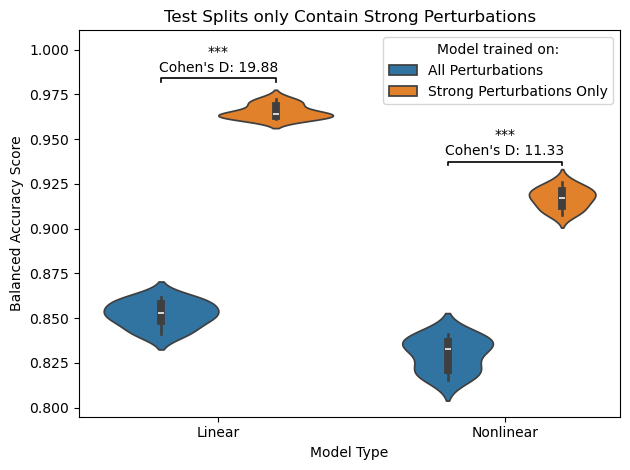

In [50]:
# get statistics
comp_stats = []
for model_type in ['Linear', 'Nonlinear']:
    res_sub = res[res.model == model_type].copy()
    a = res_sub[res_sub.train_data == 'subset']['accuracy'].values
    b = res_sub[res_sub.train_data == 'full']['accuracy'].values

    pval = stats.mannwhitneyu(a, b, alternative = 'greater').pvalue
    cd = cohens_d(a, b)
    
    comp_stats.append(
        {'model': model_type,
         'pval': pval, 
        'cd': cd}
    )
comp_stats = pd.DataFrame(comp_stats)


# ---- your plot ----
fig, ax = plt.subplots()

sns.violinplot(
    data=res, x='model', y='accuracy', hue='train_data',
    ax=ax, dodge=True
)

ax.set_xlabel('Model Type')
ax.set_ylabel('Balanced Accuracy Score')

handles, labels = ax.get_legend_handles_labels()
new_labels = ["All Perturbations", "Strong Perturbations Only"]
ax.legend(handles, new_labels)
ax.legend_.set_title("Model trained on:")
ax.set_title('Test Splits only Contain Strong Perturbations')

# Add bars using comp_stats (columns: model, pval, cd)
add_modelwise_hue_bars(ax, res, comp_stats)

plt.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_subset_performance_direct_comparison.png'),
            dpi=300, bbox_inches="tight")


Given that the model trained on strong perturbations outperforms that trained on all, these results support the notion of subsetting on the perturbations.

## Model Trained on Weak Perturbations vs Strong Perturbations


Another control is to subset to 5 perturbations that are not in the top 5 and demonstrate worse model performance here (so it's not just having fewer perturbations). This shows that it's not just about reducing the # of labels/perturbations, but about specifically selecting the strong ones.

Here, we identify 10 perturbation sets of perturbations that satisfy the following:
- The perturbation set is equal to the size of the "strong" set (5 strong + CTRL = 6 labels)
- No perturbation in the set is categorized as "strong" and no perturbation is CTRL
- The # of cells that fall into the weak set perturbation labels is ~= that of the strong (within +- 10% of the # of cells in the strong perturbation labels)
- The frequency of labels is ~= that of the strong (withing +- 2.5 percentage points)

In [44]:
if not os.path.isfile(os.path.join(data_path, 'processed', author + '_subset_performance_weak_comparison.csv')):

    # create subsets
    weak_perts = pert_strength[~pert_strength.strong].perturbation.tolist()
    weak_perts.remove('CTRL')

    tf_adata_strong = tf_adata[tf_adata.obs[pert_col].isin(strong_perts)].copy()

    rng = np.random.default_rng(seed)

    total_samples = tf_adata_strong.n_obs

    class_frequencies = tf_adata_strong.obs[pert_col].value_counts(normalize = True).values

    n_weak_sets = 10
    weak_sets = []

    # tolerances
    tot_sample_range = total_samples * 0.1
    freq_tol = 0.025

    # initialization of values
    max_attempts = 1000
    counter = 0


    while len(weak_sets) < n_weak_sets and (counter < max_attempts):
        in_range = False

        counter += 1

        weak_perts_sub = rng.choice(weak_perts, replace=False, size=len(strong_perts))

        weak_key = tuple(sorted(weak_perts_sub))
        if weak_key in weak_sets:
            continue

        tf_adata_weak = tf_adata[tf_adata.obs[pert_col].isin(weak_perts_sub)].copy()

        # ensure tf_adata_weak samples ~= total_samples
        in_sample_range = tf_adata_weak.n_obs  >= (total_samples - tot_sample_range) and tf_adata_weak.n_obs <= (total_samples + tot_sample_range)
        if not in_sample_range:
            continue

        # ensure tf_adata_weak frequencies ~= class_frequencies
        weak_freq = tf_adata_weak.obs[pert_col].value_counts(normalize=True)
        in_freq_range = np.all(np.abs(weak_freq - class_frequencies) < freq_tol)

        in_range = in_freq_range and in_sample_range
        if in_range:
            weak_sets.append(weak_key)

            print('Yes: {}'.format(len(weak_sets)))
            print('-------')

        if counter % 10 == 0:
            print('Iteration: {}'.format(counter))

In [45]:
# weak_sets = [('FGF10', 'FGF2', 'HGF', 'IGF1', 'OSM', 'TNFA'),
#  ('ADIPOQ', 'FGF2', 'IGF1', 'IL17A', 'OSM', 'TNFA'),
#  ('ADIPOQ', 'FGF10', 'FGF2', 'IGF1', 'LEP', 'TNFA'),
#  ('ADIPOQ', 'CHIR99021', 'FGF2', 'HGF', 'IGF1', 'TNFA'),
#  ('CHIR99021', 'EGF', 'FGF10', 'IGF1', 'OSM', 'TNFA'),
#  ('CHIR99021', 'EGF', 'HGF', 'IGF1', 'LEP', 'TNFA'),
#  ('FGF10', 'HGF', 'IGF1', 'LEP', 'OSM', 'TNFA'),
#  ('EGF', 'FGF2', 'HGF', 'IGF1', 'OSM', 'TNFA'),
#  ('CHIR99021', 'HGF', 'IGF1', 'IL17A', 'LEP', 'TNFA'),
#  ('FGF2', 'HGF', 'IGF1', 'IL17A', 'OSM', 'TNFA')]

Get the predictions on the subsets:

In [46]:
def sub_cv(pert_set, tf_adata, seed, verbose: bool = False):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)


    tf_adata_sub = tf_adata[tf_adata.obs[pert_col].isin(pert_set)].copy()
    X = tf_adata_sub.to_df().values
    y = tf_adata_sub.obs[pert_col].astype(str).values

    res = []
    for (k, (train_idx, test_idx)) in tqdm(enumerate(skf.split(X, y))):
        rng = np.random.default_rng(seed=seed + k)

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for model_type, model_base in base_models.items():
            if verbose:
                print('------------------------------------------------------------------------------------------')
                print('Fold: {} | Model Type: {}'.format(k, model_type))
            model = clone(model_base)

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            ba = balanced_accuracy_score(y_test, y_pred)   


            res.append({
                "fold": k,
                "model": model_type,
                "accuracy": ba
            })
        
    return pd.DataFrame(res)

In [58]:
if not os.path.isfile(os.path.join(data_path, 'processed', author + '_subset_performance_weak_comparison.csv')):
    res_strong = sub_cv(pert_set = strong_perts, tf_adata = tf_adata, seed = seed + 1, verbose = False)
    res_strong['set_type'] = 'strong'
    res_all = [res_strong]

    for (i, weak_perts) in enumerate(weak_sets):
        print(i)
        res_weak = sub_cv(pert_set = weak_perts, tf_adata = tf_adata, seed = seed + i + 2, verbose = False)
        res_weak['set_type'] = 'weak_{}'.format(i)
        res_all.append(res_weak)

    res_all = pd.concat(res_all)
    res_all.to_csv(os.path.join(data_path, 'processed', author + '_subset_performance_weak_comparison.csv'))
else:
    res_all = pd.read_csv(os.path.join(data_path, 'processed', 
                                     author + '_subset_performance_weak_comparison.csv'), 
                        index_col = 0)
    res_all.set_type = pd.Categorical(
        res_all.set_type.apply(lambda x: x.split('_')[0]), categories = ['weak', 'strong'], ordered = True)

    res_all.model = pd.Categorical(res_all.model, categories = ['Linear', 'Nonlinear'], ordered = True)


In [60]:
# get statistics
comp_stats = []
for model_type in ['Linear', 'Nonlinear']:
    res_sub = res_all[res_all.model == model_type].copy()
    a = res_sub[res_sub.set_type == 'strong']['accuracy'].values
    b = res_sub[res_sub.set_type == 'weak']['accuracy'].values

    pval = stats.mannwhitneyu(a, b, alternative = 'greater').pvalue
    cd = cohens_d(a, b)
    
    comp_stats.append(
        {'model': model_type,
         'pval': pval, 
        'cd': cd}
    )
comp_stats = pd.DataFrame(comp_stats)




fig, ax = plt.subplots()



sns.violinplot(
    data=res_all, x='model', y='accuracy', hue='set_type',
    ax=ax, dodge=True
)

ax.set_xlabel('Model Type')
ax.set_ylabel('Balanced Accuracy Score')
ax.set_title('Equal No. of Perturbation Labels')

handles, labels = ax.get_legend_handles_labels()
new_labels = ["Weak Perturbations", "Strong Perturbations"]
ax.legend(handles, new_labels)
ax.legend_.set_title("Model trained on:")


add_modelwise_hue_bars(ax, res, comp_stats)

plt.tight_layout()
fig.savefig(os.path.join(data_path, 'figures',
                         author + '_subset_performance_weak_comparison.png'),
            dpi=300, bbox_inches="tight")

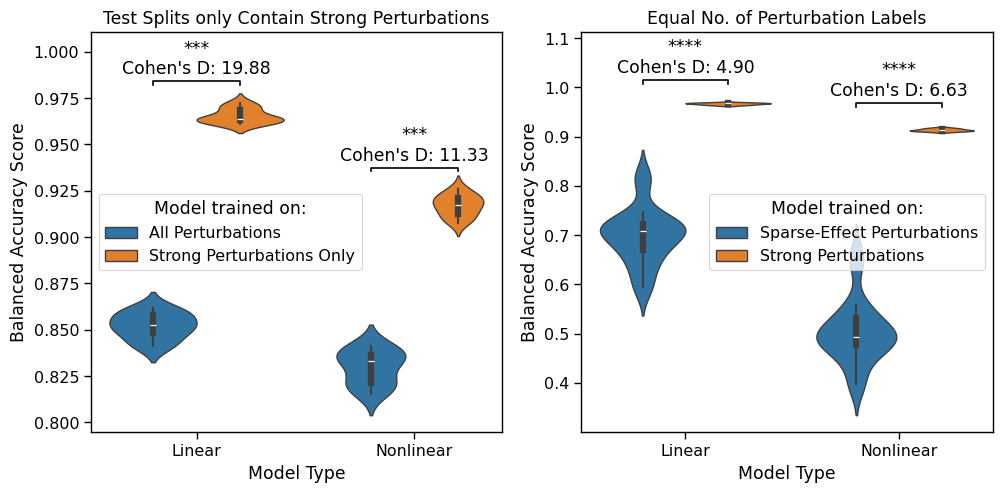

In [68]:
# get statistics for left panel
comp_stats_left = []
for model_type in ['Linear', 'Nonlinear']:
    res_sub = resA[resA.model == model_type].copy()
    a = res_sub[res_sub.train_data == 'subset']['accuracy'].values
    b = res_sub[res_sub.train_data == 'full']['accuracy'].values
    pval = stats.mannwhitneyu(a, b, alternative='greater').pvalue
    cd = cohens_d(a, b)
    comp_stats_left.append({'model': model_type, 'pval': pval, 'cd': cd})
comp_stats_left = pd.DataFrame(comp_stats_left)

# get statistics for right panel
comp_stats_right = []
for model_type in ['Linear', 'Nonlinear']:
    res_sub = res_all[res_all.model == model_type].copy()
    a = res_sub[res_sub.set_type == 'strong']['accuracy'].values
    b = res_sub[res_sub.set_type == 'weak']['accuracy'].values
    pval = stats.mannwhitneyu(a, b, alternative='greater').pvalue
    cd = cohens_d(a, b)
    comp_stats_right.append({'model': model_type, 'pval': pval, 'cd': cd})
comp_stats_right = pd.DataFrame(comp_stats_right)

with sns.plotting_context('paper', font_scale=1.3):
    fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(5.1 * 2, 5.1))

    # ---- Left panel ----
    ax = axes[0]
    sns.violinplot(
        data=resA, x='model', y='accuracy', hue='train_data',
        ax=ax, dodge=True
    )
    ax.set_xlabel('Model Type')
    ax.set_ylabel('Balanced Accuracy Score')
    ax.set_title('Test Splits only Contain Strong Perturbations')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ["All Perturbations", "Strong Perturbations Only"],
              title="Model trained on:")

    add_modelwise_hue_bars(ax, resA, comp_stats_left)

    # ---- Right panel ----
    ax = axes[1]
    sns.violinplot(
        data=res_all, x='model', y='accuracy', hue='set_type',
        ax=ax, dodge=True
    )
    ax.set_xlabel('Model Type')
    ax.set_ylabel('Balanced Accuracy Score')
    ax.set_title('Equal No. of Perturbation Labels')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ["Sparse-Effect Perturbations", "Strong Perturbations"],
              title="Model trained on:")

    add_modelwise_hue_bars(ax, res, comp_stats_right)

    plt.tight_layout()
    fig.savefig(os.path.join(data_path, 'figures', author + '_subset_performance_combined.png'),
                dpi=600, bbox_inches="tight")